# `amount_tsh` 01: basic `numeric` breakdown

**Purpose:** apply the analysis that is always performed for this feature
type, without mixing in cross-feature interpretation.

**Current role:** `candidate`

**Provisional disposition:** retain with availability and positive-magnitude treatment


## Standard checks for `numeric`

        Every predictor with this audit type receives the same basic checks:

        - dtype and numeric coercion
- explicit missingness and feature-specific sentinels
- quantiles, skew, zero/negative support and extreme values
- training/test distribution stability

        This notebook stays descriptive. Target interpretation belongs in notebook 02,
        and cross-feature relationships belong in notebook 03.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_stage_directory():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "data" / "TrainingSetValues.csv").exists()
            and (candidate / "src" / "source_data_validation.py").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the stage-1-pump-it-up directory.")


stage_directory = find_stage_directory()
source_directory = str((stage_directory / "src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from predictor_audit import (
    analysis_categories,
    categorical_summary,
    categorical_target_profile,
    category_frequency_table,
    numeric_summary,
    numeric_target_summary,
    related_feature_summary,
    sentinel_mask,
    source_blank_mask,
    text_normalisation_summary,
)
from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = stage_directory / "data"
training_features = pd.read_csv(
    data_directory / "TrainingSetValues.csv",
    keep_default_na=False,
)
training_labels = pd.read_csv(
    data_directory / "TrainingSetLabels.csv",
    keep_default_na=False,
)
test_features = pd.read_csv(
    data_directory / "TestSetValues.csv",
    keep_default_na=False,
)

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)

feature = 'amount_tsh'
feature_metadata = {'order': 1, 'name': 'amount_tsh', 'audit_type': 'numeric', 'role': 'candidate', 'disposition': 'retain with availability and positive-magnitude treatment', 'finding': 'Zero dominates the supplied values and positive amounts are strongly right-skewed.', 'decision': 'Keep an amount-recorded indicator and compare raw or transformed positive magnitude inside validation.', 'risk': 'Zero can mean no recorded amount rather than a genuine measured zero.', 'sentinel_values': [0], 'related': [{'feature': 'payment_type', 'reason': 'Payment arrangement provides the closest semantic context for a recorded tariff amount.'}, {'feature': 'quantity', 'reason': 'Water availability may influence whether an amount is charged or recorded.'}]}
feature_types = {'amount_tsh': 'numeric', 'date_recorded': 'date', 'funder': 'high-cardinality-category', 'gps_height': 'numeric', 'installer': 'high-cardinality-category', 'longitude': 'coordinate', 'latitude': 'coordinate', 'wpt_name': 'high-cardinality-category', 'num_private': 'numeric', 'basin': 'category', 'subvillage': 'high-cardinality-category', 'region': 'category', 'region_code': 'category', 'district_code': 'category', 'lga': 'category', 'ward': 'high-cardinality-category', 'population': 'numeric', 'public_meeting': 'binary', 'recorded_by': 'constant', 'scheme_management': 'category', 'scheme_name': 'high-cardinality-category', 'permit': 'binary', 'construction_year': 'year', 'extraction_type': 'category', 'extraction_type_group': 'category', 'extraction_type_class': 'category', 'management': 'category', 'management_group': 'category', 'payment': 'category', 'payment_type': 'category', 'water_quality': 'category', 'quality_group': 'category', 'quantity': 'category', 'quantity_group': 'category', 'source': 'category', 'source_type': 'category', 'source_class': 'category', 'waterpoint_type': 'category', 'waterpoint_type_group': 'category'}
assert feature in training_features.columns
print(
    f"Validated {len(training_features):,} training rows and "
    f"{len(test_features):,} test rows for {feature}."
)


Validated 59,400 training rows and 14,850 test rows for amount_tsh.


## Distribution, sentinels and coverage


In [2]:
sentinel_values = [0]
summary = numeric_summary(
    training_features,
    test_features,
    [feature],
    sentinel_values_by_column={feature: sentinel_values},
)
display(summary)


rows  missing  sentinel rows  zero rows  negative rows  \
feature    frame                                                               
amount_tsh training  59400        0          41639      41639              0   
           test      14850        0          10410      10410              0   

                     unique  minimum  p01  median     mean     p99   maximum  \
feature    frame                                                               
amount_tsh training      98      0.0  0.0     0.0  317.650  5000.0  350000.0   
           test          68      0.0  0.0     0.0  322.827  5000.0  200000.0   

                     skewness  
feature    frame               
amount_tsh training    57.808  
           test        43.858

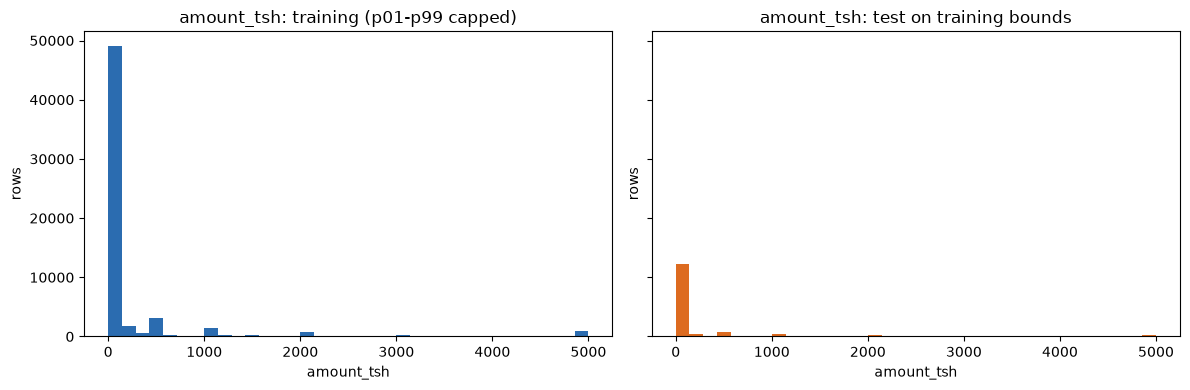

,training rows,test rows
amount_tsh,,
0.0,41639,10410
500.0,3102,772
50.0,2472,631
1000.0,1488,370
20.0,1463,349
200.0,1220,296
100.0,816,218
10.0,806,189
30.0,743,186


In [3]:
training_values = pd.to_numeric(training_features[feature], errors="coerce")
test_values = pd.to_numeric(test_features[feature], errors="coerce")
lower = training_values.quantile(0.01)
upper = training_values.quantile(0.99)
bins = np.linspace(lower, upper, 36)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
axes[0].hist(training_values.clip(lower, upper), bins=bins, color="#2b6cb0")
axes[0].set_title(f"{feature}: training (p01-p99 capped)")
axes[1].hist(test_values.clip(lower, upper), bins=bins, color="#dd6b20")
axes[1].set_title(f"{feature}: test on training bounds")
for axis in axes:
    axis.set_xlabel(feature)
    axis.set_ylabel("rows")
plt.tight_layout()
plt.show()

top_values = pd.DataFrame({
    "training rows": training_values.value_counts().head(12),
    "test rows": test_values.value_counts().head(12),
}).fillna(0).astype(int)
display(top_values)


## Basic-breakdown handoff

The outputs above establish shape, missingness, support and supplied
train/test coverage. They do not by themselves establish usefulness or a
causal explanation. Notebook 02 interprets noteworthy single-feature
evidence; notebook 03 tests the explicitly related predictors.
